# Multiple Instance Learning

In [1]:
from mil.models import MIL_model, MLP_encoder
import mil.models as models
from mil.training_utils import model_run, set_seed
from mil.evaluation_utils import evaluate_accuracy
from mil.CustomDataloader import CustomLoader
from mil.CellsData import CellsData

from mil import PROJECT_ROOT

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
# Set to True if you want to use original sparse matrix data, False if you want low dimensional embeddings
use_sparse_data = False


if use_sparse_data:
    INPUT_SIZE = 2000
    BAG_KEY = 'bag'
    NUM_EPOCHS = 30
else:
    INPUT_SIZE = 30
    BAG_KEY = 'bag_embed'
    NUM_EPOCHS = 30

In [3]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

n_bags = sum([len(el) for el in (train_set, val_set, test_set)])
print(f"The entire datatset contains {n_bags} bags.")

train_loader = CustomLoader(train_set, batchsize=20)
validation_loader = CustomLoader(val_set, batchsize=20)
test_loader = CustomLoader(test_set, batchsize=20)

The entire datatset contains 146 bags.


In [4]:
def run_evaluation(encoder: nn.Module, aggregator: nn.Module, lr: float, decay: float, plot_title: str, path_prefix: str):
    model = MIL_model(instance_encoder=encoder, bag_aggregator=aggregator)


    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)

    fig, ax = plt.subplots()


    train_loss, valid_loss, best_epoch = model_run(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        save_path_prefix=path_prefix,
        ax=ax,
        plot_title=plot_title,
        sparse=use_sparse_data,
        save_weights=True,
    )

    path = path_prefix + f"{best_epoch}.torch"
    model = torch.load(path, weights_only=False)
    print(model.get_details())
    evaluate_accuracy(model=model, dataset=test_set, bag_key = BAG_KEY, mode = 'Test')

# Mean aggregation

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/viktor/.netrc.
wandb: Currently logged in as: viktor-prochazka2016 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Min valid loss: Epoch 1, 0.3060


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▂
val_loss,▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▂▃▂▃▃▃▃▄▃▄▃█
epoch,30
train_loss,0.11953
val_loss,2.23475


{'encoder': 'MLP_enxoder', 'n_hidden': 1, 'hidden_size': 30, 'input_size': 30, 'aggregator': 'MeanAggergation', 'encoding_size': 30}

Accuracy: 63.64%
Balanced Accuracy: 61.90%
Precision: 60.68%
Recall: 61.90%


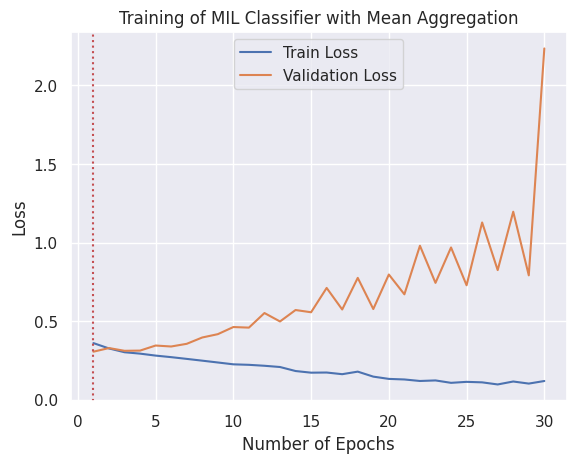

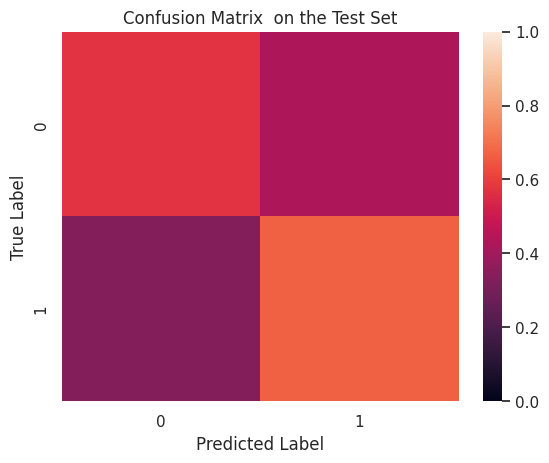

In [5]:
run_params = {}
if use_sparse_data:
    run_params = {
        "aggregator": "MeanAggergation",
        "n_hidden": 3,
        "hidden_size": 10,
        "encoding_size": 10,
        "seed": 37,
        "lr": 10**-2,
        "decay": 10**-2,
    }
else:
    run_params = {
        "aggregator": "MeanAggergation",
        "n_hidden": 1,
        "hidden_size": 30,
        "seed": 27,
        "encoding_size": 30,
        "lr": 10**-2,
        "decay": 10**-1.7005985187830885,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params["aggregator"])(encoding_size=run_params["encoding_size"])

run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Mean Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/torch_playground_mean_aggregation_models/epoch_")
)

## Maximum aggregation

Min valid loss: Epoch 5, 0.2796


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,▇▇█▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▂▂▁▁▁▁▁
val_loss,▄▂▂▂▁▂▁▁▂▁▂▂▂▂▃▄▂▄▅▃▆▄█▄▇▆▇███
epoch,30
train_loss,0.05325
val_loss,0.75463


{'encoder': 'MLP_enxoder', 'n_hidden': 1, 'hidden_size': 30, 'input_size': 30, 'aggregator': 'MaxAggregation', 'encoding_size': 30}

Accuracy: 63.64%
Balanced Accuracy: 65.71%
Precision: 63.64%
Recall: 65.71%


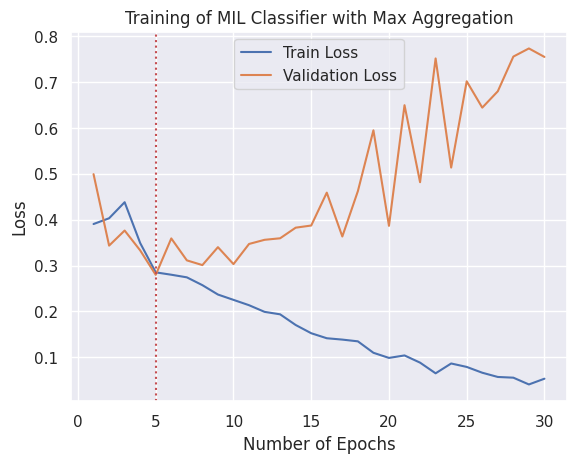

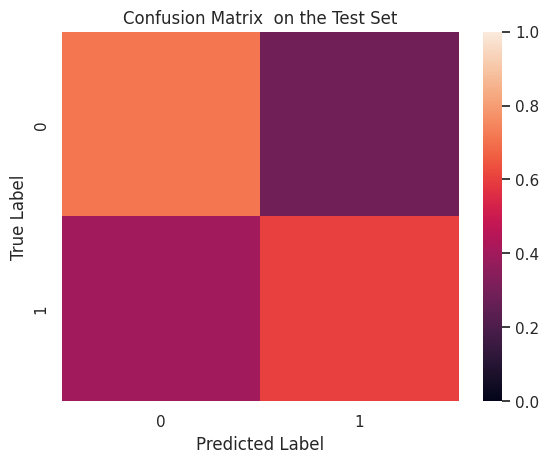

In [6]:
run_params = {}
if use_sparse_data:
    run_params = {
        "aggregator": "MaxAggergation",
        "n_hidden": 3,
        "hidden_size": 10,
        "encoding_size": 10,
        "seed": 37,
        "lr": 10**-2,
        "decay": 10**-2,
    }
else:
    run_params = {
        "aggregator": "MaxAggergation",
        "n_hidden": 1,
        "hidden_size": 30,
        "seed": 27,
        "encoding_size": 30,
        "lr": 10**-2,
        "decay": 10**-1.7005985187830885,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params["aggregator"])(encoding_size=run_params["encoding_size"])

run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Max Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/torch_playground_max_aggregation_models/epoch_")
)

## Attention Aggregation

Min valid loss: Epoch 4, 0.3053


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▂▃▃
val_loss,▂▁▁▁▁▁▁▁▁▂▁▃▃▂▃▄▅▅▄▅▆▆▅▆▇█▇▅▆▇
epoch,30
train_loss,0.15733
val_loss,1.08994


{'encoder': 'MLP_enxoder', 'n_hidden': 3, 'hidden_size': 40, 'input_size': 30, 'aggregator': 'AttentionAggregation', 'encoding_size': 40, 'attention_hidden_size': 10}

Accuracy: 77.27%
Balanced Accuracy: 71.90%
Precision: 73.96%
Recall: 71.90%


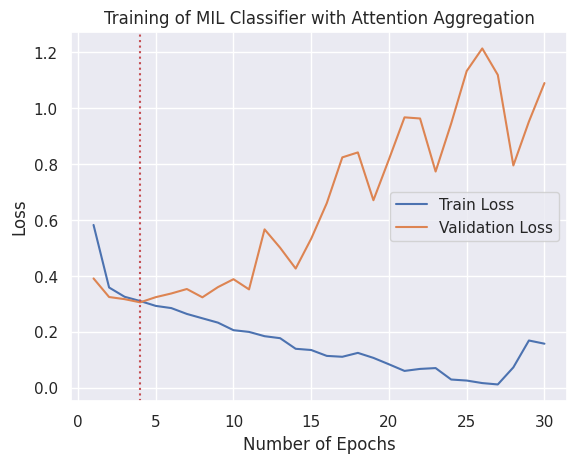

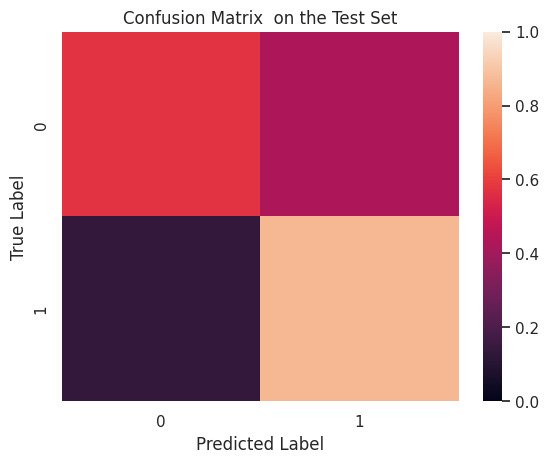

In [7]:
run_params={}

if use_sparse_data:
    run_params={
        "aggregator": "AttentionAggregation",
        "encoding_size": 10,
        "attention_hidden_size": 10,
        "hidden_size": 10,
        "n_hidden": 3,
        "seed": 2023,
        "lr": 10**-3,
        "decay": 10**-2,
    }
      
    
else:
    run_params={
        "aggregator": "AttentionAggregation",
        "encoding_size": 40,
        "attention_hidden_size": 10,
        "hidden_size": 40,
        "n_hidden": 3,
        "seed": 42,
        "lr": 10**-2,
        "decay": 10**-2,
    }

set_seed(run_params["seed"])

encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params["aggregator"])(encoding_size=run_params["encoding_size"], attention_hidden_size=run_params["attention_hidden_size"])
run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Attention Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/attention_aggregation_models/epoch_")
)

## Gated Attention Aggregation

Min valid loss: Epoch 7, 0.2807


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
val_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▂▃▄▃▃▄▄▄▇███▇
epoch,30
train_loss,0.01179
val_loss,2.17518


{'encoder': 'MLP_enxoder', 'n_hidden': 2, 'hidden_size': 43, 'input_size': 30, 'aggregator': 'GatedAttentionAggregation', 'encoding_size': 4, 'attention_hidden_size': 42}

Accuracy: 72.73%
Balanced Accuracy: 68.57%
Precision: 68.57%
Recall: 68.57%


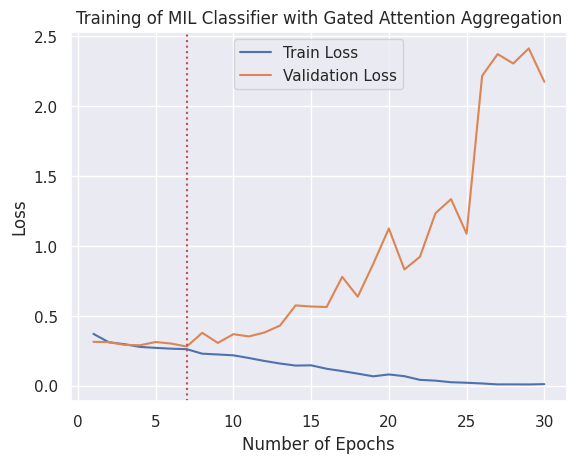

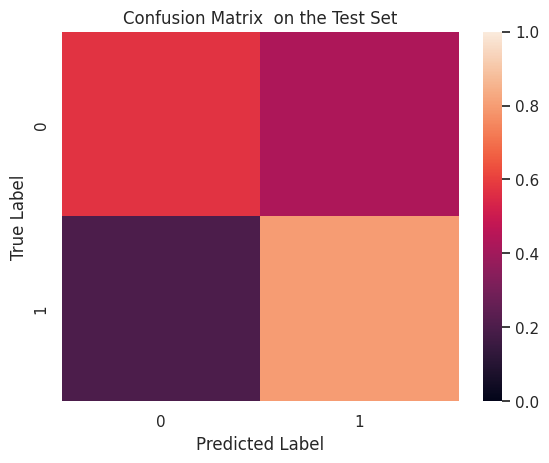

In [8]:
run_params = {}

if use_sparse_data:
    run_params = {
        "aggregator": "GatedAttentionAggregation",
        "encoding_size": 10,
        "attention_hidden_size": 10,
        "hidden_size": 20,
        "n_hidden": 3,
        "seed": 0,
        "lr": 10**-2,
        "decay": 10**-2,
    }
else:
    run_params = {
        "aggregator": "GatedAttentionAggregation",
        "encoding_size": 4,
        "attention_hidden_size": 42,
        "hidden_size": 43,
        "n_hidden": 2,
        "seed": 0,
        "lr": 10**-2,
        "decay": 10**-2,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"],
    hidden_size=run_params["hidden_size"],
    output_size=run_params["encoding_size"],
    input_size=INPUT_SIZE
)
aggregator = getattr(models, run_params["aggregator"])(
    encoding_size=run_params["encoding_size"], 
    attention_hidden_size=run_params["attention_hidden_size"]
)

run_evaluation(
    encoder,
    aggregator,
    run_params["lr"],
    run_params["decay"],
    plot_title="Training of MIL Classifier with Gated Attention Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/gated_attention_aggregation_models/epoch_")
)